# Milestone 1: Background Research + Top Similar Markets

**Project:** Break Through Tech AI Studio, Fall 2026  
**Company / Challenge:** Estée Lauder / Jo Malone-style simulated digital fragrance advisor rollout  
**Assigned section:** Task #5, background research + top 3 similar markets  
**Primary metric:** `revenue_per_session`

This notebook turns our Milestone 1 assigned section into a reproducible Jupyter workflow. It includes the project framing, dataset loading, preprocessing checks, exploratory visuals, and a data-driven market similarity ranking to identify the top comparison markets for the U.S. pilot market.

## 1. Milestone 1 Objective

The September milestone is about understanding the business question, reviewing the simulated market-week dataset, completing initial EDA, defining the pilot and comparison markets, and using visualizations to motivate why simple before/after analysis may be misleading.

For our assigned part, the specific goal is:

1. Document the qualitative launch context from the project materials.
2. Use pre-launch data to compare candidate markets to the U.S. pilot market.
3. Identify the top 3 similar markets to support the next Difference-in-Differences milestone.
4. Create clean visuals and summary tables that the team can reuse in the final milestone packet.

## 2. Project Background

The project uses a fully simulated market-week e-commerce panel to estimate the business impact of a simulated digital fragrance-advisor feature. The feature becomes available in a pilot market, and the team must estimate whether the rollout improved fragrance performance.

This is a causal inference project, not a standard prediction project. The core question is not just whether performance increased after launch. The stronger question is whether performance improved more in the pilot market than it would have without the rollout.

The dataset intentionally includes complications that make naive analysis risky, including non-random control selection, possible anticipation effects, overlapping paid media, promotional activity, and potential spillover concerns. That is why this notebook focuses on pre-period similarity and control-market credibility.

In [15]:
# Core imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

# Resolve the repo root by walking up to the folder containing data/, so this
# notebook runs from any depth. (Replaces a hardcoded candidate list that
# included an absolute /mnt/data path from the original author's machine.)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'data' / 'market_week_data.csv').exists())

DATA_PATH = ROOT / 'data' / 'market_week_data.csv'
FIG_DIR = ROOT / 'figures' / 'eda'
OUT_DIR = ROOT / 'outputs'
FIG_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR.mkdir(exist_ok=True, parents=True)

print('Using data file:', DATA_PATH)

Using data file: /drive/Untitled Folder/EsteeLauder/data/market_week_data.csv


## 3. Load the Data

Each row is a market-week observation. The most important fields for this milestone are:

- `market`
- `week_index`
- `week_start`
- `revenue_per_session`
- `conversion_rate`
- `average_order_value`
- `paid_media_index`
- `promo_intensity`
- `new_visitor_share`
- `pilot_market`
- `post_launch`
- `digital_feature_available`
- `weeks_from_launch`

In [16]:
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print()
print('Columns:')
print(df.columns.tolist())

display(df.head())

Shape: (728, 16)

Columns:
['market', 'week_index', 'week_start', 'sessions', 'fragrance_orders', 'fragrance_revenue', 'conversion_rate', 'average_order_value', 'revenue_per_session', 'paid_media_index', 'promo_intensity', 'new_visitor_share', 'pilot_market', 'post_launch', 'digital_feature_available', 'weeks_from_launch']


,market,week_index,week_start,sessions,fragrance_orders,fragrance_revenue,conversion_rate,average_order_value,revenue_per_session,paid_media_index,promo_intensity,new_visitor_share,pilot_market,post_launch,digital_feature_available,weeks_from_launch
0,Australia,0,2025-01-06,69314,1870,147050.31,0.026979,78.64,2.1215,96.81,0.2081,0.3308,0,0,0,-65
1,Australia,1,2025-01-13,71010,2011,159108.26,0.028320,79.12,2.2406,100.78,0.2142,0.3870,0,0,0,-64
2,Australia,2,2025-01-20,71268,1954,150249.86,0.027418,76.89,2.1082,89.21,0.2005,0.3705,0,0,0,-63
3,Australia,3,2025-01-27,67993,1632,128219.61,0.024002,78.57,1.8858,104.77,0.2123,0.3519,0,0,0,-62
4,Australia,4,2025-02-03,68280,1952,161268.21,0.028588,82.62,2.3619,101.49,0.1982,0.3558,0,0,0,-61


## 4. Preprocessing and Data Checks

Before choosing similar markets, we convert dates, sort the panel, check missing values, check duplicates, and identify the pilot market and launch date.

In [17]:
# Preprocessing
clean = df.copy()
clean['week_start'] = pd.to_datetime(clean['week_start'])
clean = clean.sort_values(['market', 'week_index']).reset_index(drop=True)

# Basic validation
missing = clean.isna().sum().to_frame('missing_values')
duplicates = clean.duplicated(subset=['market', 'week_index']).sum()
markets = sorted(clean['market'].unique())

pilot_market = clean.loc[clean['pilot_market'] == 1, 'market'].mode()[0]
launch_week = int(clean.loc[clean['digital_feature_available'] == 1, 'week_index'].min())
launch_date = clean.loc[clean['week_index'] == launch_week, 'week_start'].min()
primary_metric = 'revenue_per_session'

print('Number of rows:', len(clean))
print('Number of markets:', clean['market'].nunique())
print('Markets:', markets)
print('Duplicate market-week rows:', duplicates)
print('Pilot market:', pilot_market)
print('Launch week:', launch_week)
print('Launch date:', launch_date.date())
print('Primary metric:', primary_metric)
print()
print('Missing values:')
display(missing[missing['missing_values'] > 0])

if missing['missing_values'].sum() == 0:
    print('No missing values detected.')

Number of rows: 728
Number of markets: 7
Markets: ['Australia', 'Canada', 'France', 'Germany', 'Japan', 'United Kingdom', 'United States']
Duplicate market-week rows: 0
Pilot market: United States
Launch week: 65
Launch date: 2026-04-06
Primary metric: revenue_per_session

Missing values:


,missing_values


No missing values detected.


In [18]:
# Create pre/post subsets
pre = clean[clean['week_index'] < launch_week].copy()
post = clean[clean['week_index'] >= launch_week].copy()
controls = [m for m in markets if m != pilot_market]

print('Pre-period weeks:', pre['week_index'].nunique())
print('Post-period weeks:', post['week_index'].nunique())
print('Control candidates:', controls)

Pre-period weeks: 65
Post-period weeks: 39
Control candidates: ['Australia', 'Canada', 'France', 'Germany', 'Japan', 'United Kingdom']


## 5. Visual EDA: Revenue per Session by Market

This chart is the first milestone-level view of the business metric. The vertical line marks the launch week. The goal is to inspect whether the U.S. pilot market visibly changes after launch and whether other markets show similar or different movement over time.

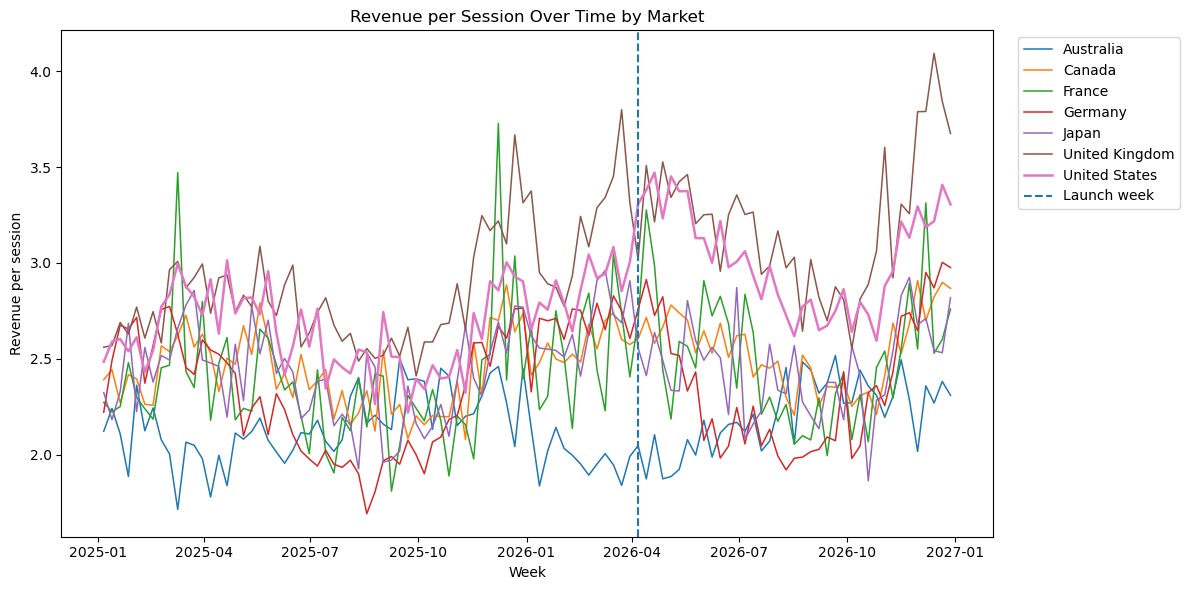

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
for market, g in clean.groupby('market'):
    ax.plot(g['week_start'], g[primary_metric], label=market, linewidth=1.8 if market == pilot_market else 1.1)

ax.axvline(launch_date, linestyle='--', linewidth=1.5, label='Launch week')
ax.set_title('Revenue per Session Over Time by Market')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue per session')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(FIG_DIR / '01_revenue_per_session_all_markets.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Pilot vs. Control Average

A simple pilot-versus-control visualization helps show why Difference-in-Differences is needed. If both the U.S. and controls move over time, a simple before/after comparison for the U.S. alone could exaggerate or understate the feature impact.

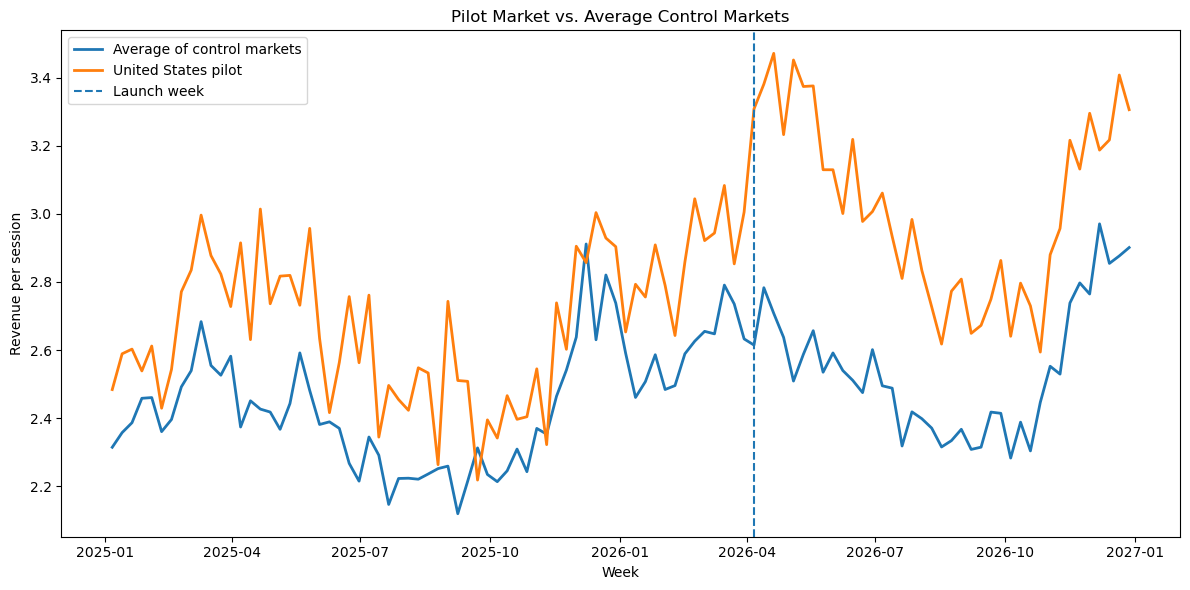

In [20]:
plot_df = clean.copy()
plot_df['group'] = np.where(plot_df['market'] == pilot_market, 'United States pilot', 'Average of control markets')
plot_summary = (
    plot_df.groupby(['group', 'week_start'], as_index=False)[primary_metric]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))
for group, g in plot_summary.groupby('group'):
    ax.plot(g['week_start'], g[primary_metric], label=group, linewidth=2)

ax.axvline(launch_date, linestyle='--', linewidth=1.5, label='Launch week')
ax.set_title('Pilot Market vs. Average Control Markets')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue per session')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '02_pilot_vs_control_average.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Simple Before/After Context

This is not the final causal estimate. It is a descriptive checkpoint that tells us how the primary metric changed before versus after launch in the pilot market and the controls.

In [21]:
before_after = (
    clean.assign(group=np.where(clean['market'] == pilot_market, 'United States pilot', 'Average controls'))
    .groupby(['group', 'post_launch'], as_index=False)[primary_metric]
    .mean()
)

before_after_pivot = before_after.pivot(index='group', columns='post_launch', values=primary_metric).rename(columns={0: 'pre_avg', 1: 'post_avg'})
before_after_pivot['change'] = before_after_pivot['post_avg'] - before_after_pivot['pre_avg']
before_after_pivot['pct_change'] = before_after_pivot['change'] / before_after_pivot['pre_avg']

display(before_after_pivot.round(4))

naive_did = before_after_pivot.loc['United States pilot', 'change'] - before_after_pivot.loc['Average controls', 'change']
print(f'Descriptive pilot-minus-control change: {naive_did:.4f} revenue/session')

post_launch,pre_avg,post_avg,change,pct_change
group,,,,
Average controls,2.4410,2.5417,0.1007,0.0413
United States pilot,2.6809,3.0230,0.3421,0.1276


Descriptive pilot-minus-control change: 0.2414 revenue/session


## 8. Qualitative Launch Context for Milestone 1

For this milestone, the key qualitative context is:

- The digital fragrance advisor is simulated as being available in the U.S. pilot market after the launch week.
- The data is simulated and intentionally includes causal complications, so the team should avoid treating before/after lift as proof of impact.
- Paid media and promotion variables are important context because they may overlap with the launch and make performance look better or worse for reasons unrelated to the advisor itself.
- The strongest next-step control markets should be chosen based on pre-launch similarity, not post-launch outcomes.
- Canada should be treated as the first-pass control candidate, while France and the United Kingdom are useful sensitivity markets for checking whether the conclusion depends on the comparison group.

## 9. Pre-Period Market Summary

The next table summarizes each market before launch. These are the inputs for selecting comparable markets.

In [22]:
summary_cols = [
    'sessions',
    'revenue_per_session',
    'conversion_rate',
    'average_order_value',
    'paid_media_index',
    'promo_intensity',
    'new_visitor_share',
]

def slope_for_metric(g, metric):
    return np.polyfit(g['week_index'], g[metric], 1)[0]

summary_rows = []
for market, g in pre.groupby('market'):
    row = {'market': market}
    for col in summary_cols:
        row[f'pre_avg_{col}'] = g[col].mean()
    row['pre_rps_trend_slope'] = slope_for_metric(g, 'revenue_per_session')
    row['pre_rps_volatility'] = g['revenue_per_session'].std()
    summary_rows.append(row)

pre_summary = pd.DataFrame(summary_rows).sort_values('market').reset_index(drop=True)
pre_summary.to_csv(OUT_DIR / 'pre_period_market_summary.csv', index=False)

display(pre_summary.round(4))

,market,pre_avg_sessions,pre_avg_revenue_per_session,pre_avg_conversion_rate,pre_avg_average_order_value,pre_avg_paid_media_index,pre_avg_promo_intensity,pre_avg_new_visitor_share,pre_rps_trend_slope,pre_rps_volatility
0,Australia,68867.3077,2.1230,0.0260,81.7009,98.4517,0.2069,0.3597,0.0007,0.1802
1,Canada,94875.4923,2.4461,0.0315,77.7249,100.3945,0.1993,0.4041,0.0017,0.1926
2,France,158147.9385,2.3911,0.0308,77.6851,102.1140,0.2248,0.4385,0.0027,0.3327
3,Germany,187444.2308,2.3682,0.0289,81.8346,99.9117,0.1864,0.3818,0.0032,0.3159
4,Japan,134393.8154,2.4496,0.0266,92.2228,98.4265,0.1795,0.3331,0.0032,0.2475
5,United Kingdom,234579.0000,2.8679,0.0379,75.6557,102.3465,0.2191,0.4517,0.0084,0.2995
6,United States,422638.9385,2.6809,0.0339,79.0862,102.9848,0.2114,0.4229,0.0027,0.2176


## 10. Similarity Method

To find the top 3 similar markets, we compare each control market to the U.S. using pre-launch data only.

The score intentionally emphasizes **behavioral and business metric similarity**, not raw market size. Raw sessions are shown in the summary table, but they are not used in the final similarity score because the main outcome is normalized as revenue per session.

The ranking uses:

- Average revenue per session
- Average conversion rate
- Average order value
- Paid media index
- Promotion intensity
- New visitor share
- Pre-period revenue-per-session trend slope
- Pre-period revenue-per-session correlation with the U.S.

Lower score means more similar to the U.S. pilot market before launch.

In [23]:
# Build similarity ranking
metric_cols = [
    'revenue_per_session',
    'conversion_rate',
    'average_order_value',
    'paid_media_index',
    'promo_intensity',
    'new_visitor_share',
]

us_row = pre_summary[pre_summary['market'] == pilot_market].iloc[0]
series = pre.pivot(index='week_index', columns='market', values='revenue_per_session')

ranking_rows = []
for market in controls:
    market_row = pre_summary[pre_summary['market'] == market].iloc[0]
    row = {'market': market}

    for col in metric_cols:
        row[f'{col}_gap'] = abs(market_row[f'pre_avg_{col}'] - us_row[f'pre_avg_{col}'])

    row['rps_gap_vs_us'] = abs(market_row['pre_avg_revenue_per_session'] - us_row['pre_avg_revenue_per_session'])
    row['rps_corr_with_us'] = series[market].corr(series[pilot_market])
    row['corr_distance'] = 1 - row['rps_corr_with_us']
    row['slope_gap_vs_us'] = abs(market_row['pre_rps_trend_slope'] - us_row['pre_rps_trend_slope'])
    row['pre_avg_rps'] = market_row['pre_avg_revenue_per_session']
    row['pre_avg_conversion_rate'] = market_row['pre_avg_conversion_rate']
    row['pre_avg_aov'] = market_row['pre_avg_average_order_value']
    row['pre_avg_paid_media_index'] = market_row['pre_avg_paid_media_index']
    row['pre_avg_promo_intensity'] = market_row['pre_avg_promo_intensity']
    row['pre_avg_new_visitor_share'] = market_row['pre_avg_new_visitor_share']
    ranking_rows.append(row)

ranking = pd.DataFrame(ranking_rows)

# Normalize gap features so no single scale dominates.
gap_cols = [f'{col}_gap' for col in metric_cols]
for col in gap_cols + ['corr_distance', 'slope_gap_vs_us']:
    max_val = ranking[col].max()
    ranking[f'{col}_norm'] = ranking[col] / max_val if max_val != 0 else 0

# Weighted score: 80% business metrics, 15% trend correlation, 5% trend slope alignment.
ranking['similarity_score'] = (
    0.80 * ranking[[f'{col}_gap_norm' for col in metric_cols]].mean(axis=1)
    + 0.15 * ranking['corr_distance_norm']
    + 0.05 * ranking['slope_gap_vs_us_norm']
)

ranking = ranking.sort_values('similarity_score').reset_index(drop=True)
ranking['rank'] = np.arange(1, len(ranking) + 1)

market_similarity_ranking = ranking[[
    'rank',
    'market',
    'similarity_score',
    'pre_avg_rps',
    'rps_gap_vs_us',
    'rps_corr_with_us',
    'slope_gap_vs_us',
    'pre_avg_conversion_rate',
    'pre_avg_aov',
    'pre_avg_paid_media_index',
    'pre_avg_promo_intensity',
    'pre_avg_new_visitor_share',
]].copy()

market_similarity_ranking.to_csv(OUT_DIR / 'market_similarity_ranking.csv', index=False)

display(market_similarity_ranking.round(4))

,rank,market,similarity_score,pre_avg_rps,rps_gap_vs_us,rps_corr_with_us,slope_gap_vs_us,pre_avg_conversion_rate,pre_avg_aov,pre_avg_paid_media_index,pre_avg_promo_intensity,pre_avg_new_visitor_share
0,1,Canada,0.2878,2.4461,0.2348,0.8596,0.0010,0.0315,77.7249,100.3945,0.1993,0.4041
1,2,France,0.2881,2.3911,0.2899,0.5499,0.0000,0.0308,77.6851,102.1140,0.2248,0.4385
2,3,United Kingdom,0.3281,2.8679,0.1870,0.6369,0.0057,0.0379,75.6557,102.3465,0.2191,0.4517
3,4,Germany,0.4843,2.3682,0.3127,0.6323,0.0004,0.0289,81.8346,99.9117,0.1864,0.3818
4,5,Australia,0.7063,2.1230,0.5580,-0.4449,0.0020,0.0260,81.7009,98.4517,0.2069,0.3597
5,6,Japan,0.7620,2.4496,0.2314,0.5549,0.0004,0.0266,92.2228,98.4265,0.1795,0.3331


## 11. Similarity Ranking Visualization

This visual makes the ranking easier to communicate in the milestone packet. Lower scores are better.

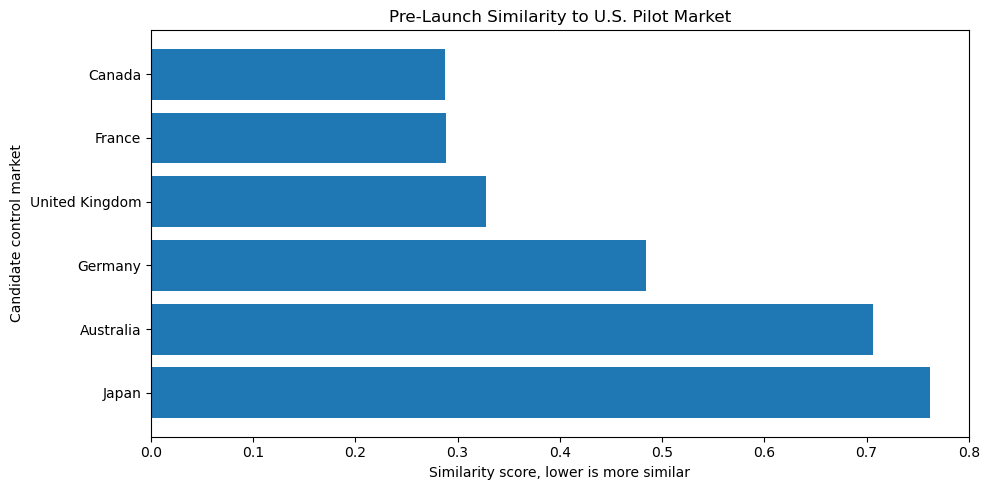

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ranked_for_plot = market_similarity_ranking.sort_values('similarity_score', ascending=True)
ax.barh(ranked_for_plot['market'], ranked_for_plot['similarity_score'])
ax.invert_yaxis()
ax.set_title('Pre-Launch Similarity to U.S. Pilot Market')
ax.set_xlabel('Similarity score, lower is more similar')
ax.set_ylabel('Candidate control market')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_market_similarity_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Top 3 Similar Markets

Based on the pre-period similarity score, the top 3 comparison markets are:

1. Canada
2. France
3. United Kingdom

Canada is the strongest first-pass control candidate. France and the United Kingdom should be used as sensitivity markets, meaning we should check whether the eventual DiD conclusion changes if these markets are included or compared separately.

In [25]:
top3_markets = market_similarity_ranking.head(3)['market'].tolist()
print('Top 3 similar markets:', top3_markets)

display(market_similarity_ranking.head(3).round(4))

Top 3 similar markets: ['Canada', 'France', 'United Kingdom']


,rank,market,similarity_score,pre_avg_rps,rps_gap_vs_us,rps_corr_with_us,slope_gap_vs_us,pre_avg_conversion_rate,pre_avg_aov,pre_avg_paid_media_index,pre_avg_promo_intensity,pre_avg_new_visitor_share
0,1,Canada,0.2878,2.4461,0.2348,0.8596,0.0010,0.0315,77.7249,100.3945,0.1993,0.4041
1,2,France,0.2881,2.3911,0.2899,0.5499,0.0000,0.0308,77.6851,102.1140,0.2248,0.4385
2,3,United Kingdom,0.3281,2.8679,0.1870,0.6369,0.0057,0.0379,75.6557,102.3465,0.2191,0.4517


## 13. Pairwise Visuals: U.S. vs. Each Top Market

These pairwise charts are directly useful for Task #5 because they show how each candidate moved compared with the U.S. before and after launch.

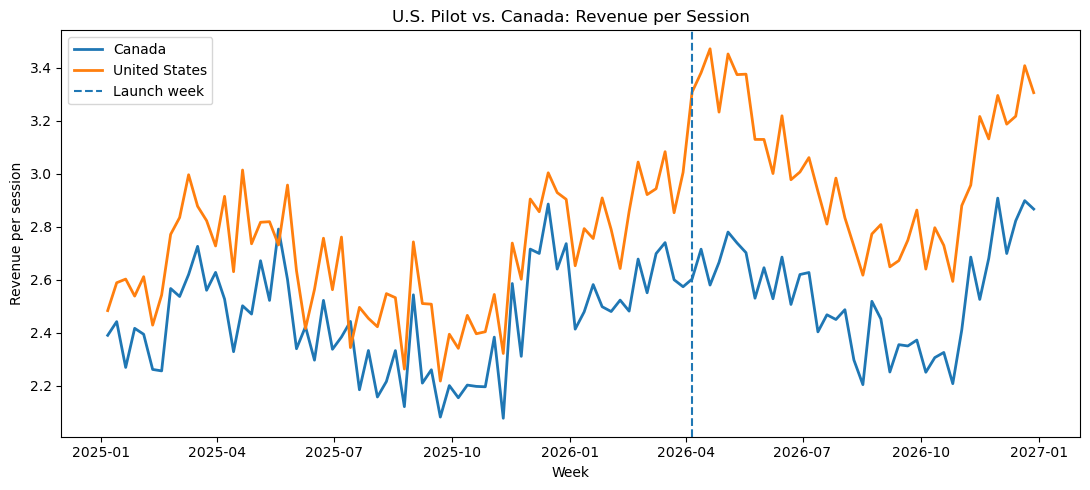

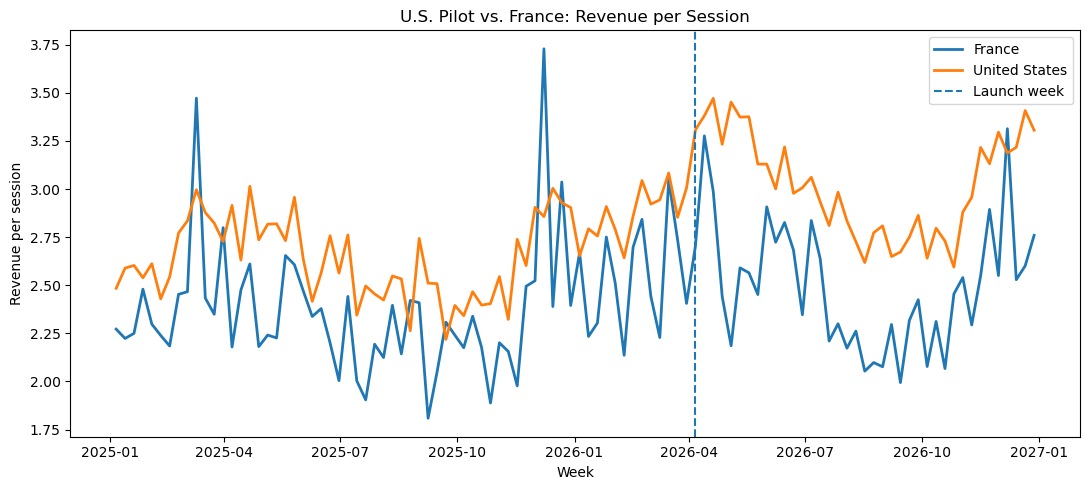

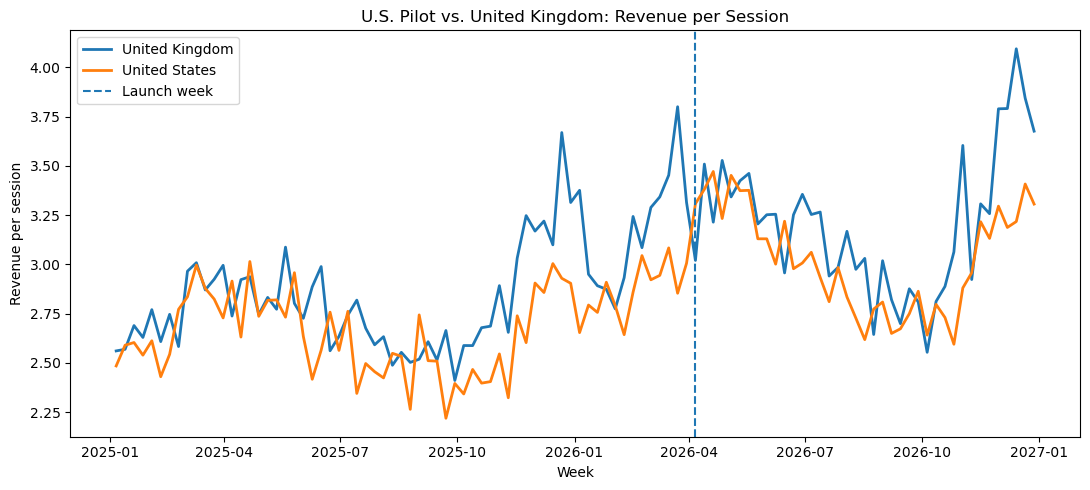

In [26]:
for market in top3_markets:
    pair = clean[clean['market'].isin([pilot_market, market])].copy()
    fig, ax = plt.subplots(figsize=(11, 5))
    for label, g in pair.groupby('market'):
        ax.plot(g['week_start'], g[primary_metric], label=label, linewidth=2)
    ax.axvline(launch_date, linestyle='--', linewidth=1.5, label='Launch week')
    ax.set_title(f'U.S. Pilot vs. {market}: Revenue per Session')
    ax.set_xlabel('Week')
    ax.set_ylabel('Revenue per session')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'04_us_vs_{market.lower().replace(" ", "_")}_rps.png', dpi=200, bbox_inches='tight')
    plt.show()

## 14. Launch Context Variables: Paid Media and Promotions

These charts help the team explain why control selection matters. If paid media or promotion intensity changes around launch, the final causal estimate may need sensitivity checks.

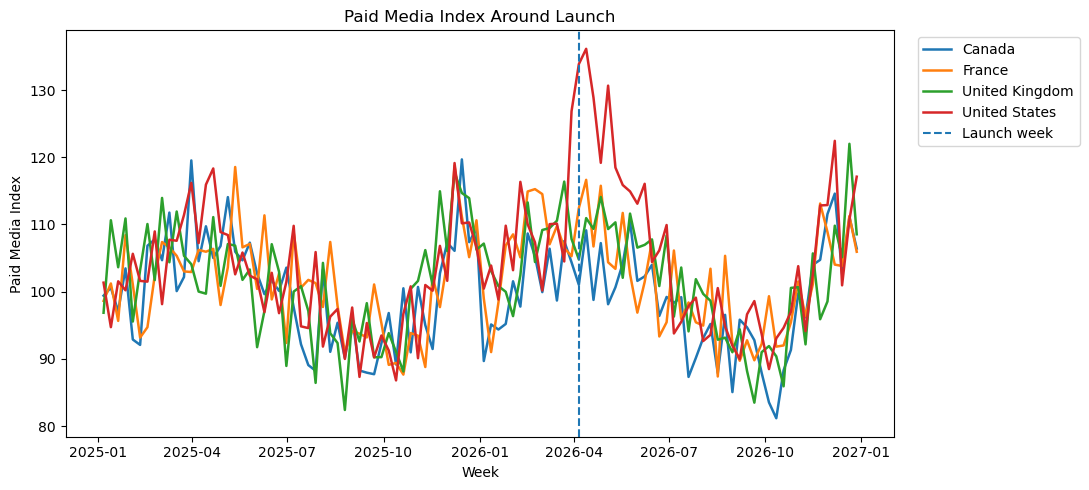

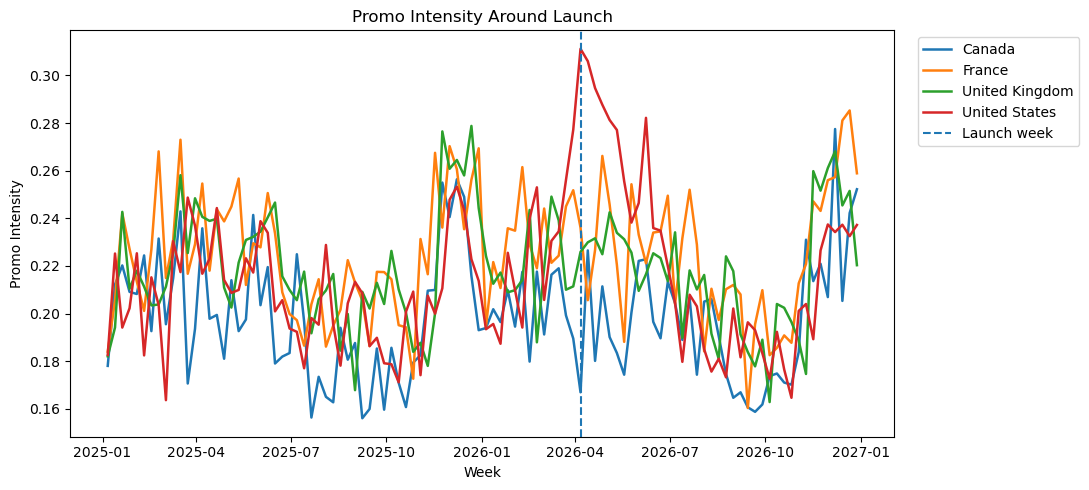

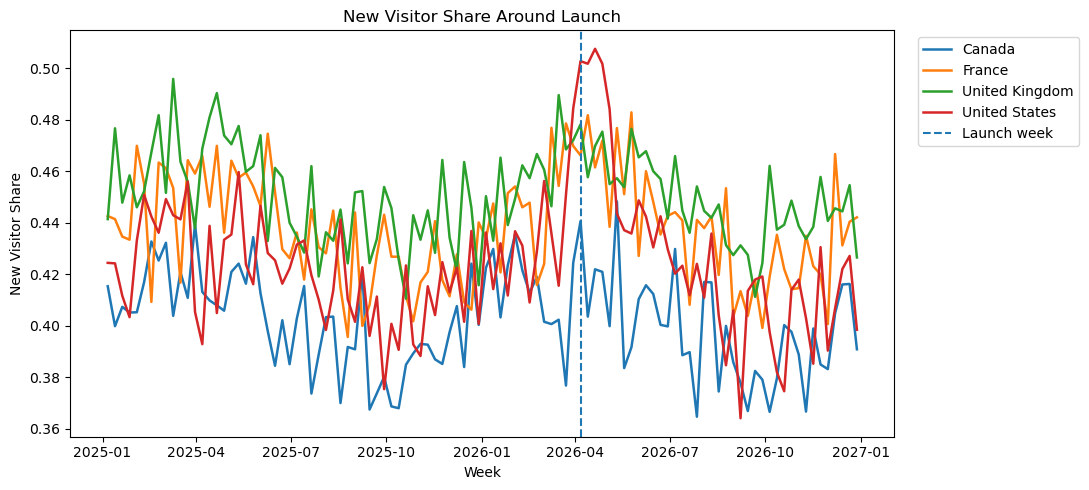

In [27]:
context_markets = [pilot_market] + top3_markets
context = clean[clean['market'].isin(context_markets)].copy()

for metric in ['paid_media_index', 'promo_intensity', 'new_visitor_share']:
    fig, ax = plt.subplots(figsize=(11, 5))
    for market, g in context.groupby('market'):
        ax.plot(g['week_start'], g[metric], label=market, linewidth=1.8)
    ax.axvline(launch_date, linestyle='--', linewidth=1.5, label='Launch week')
    ax.set_title(f'{metric.replace("_", " ").title()} Around Launch')
    ax.set_xlabel('Week')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'05_{metric}_top_markets.png', dpi=200, bbox_inches='tight')
    plt.show()

## 15. Interpretation for the Milestone 1 Write-Up

**Canada** is the strongest first-pass comparison market because it has the closest pre-period movement pattern to the U.S. on revenue per session, including the strongest pre-period correlation among the candidate control markets. Its average pre-launch revenue per session is lower than the U.S., but the direction and shape of movement are comparatively close.

**France** is a strong sensitivity market because its pre-period trend slope is very close to the U.S. and its paid media and promotion context is directionally comparable. However, the lower correlation means it should be used carefully rather than treated as the only control.

**United Kingdom** is a useful sensitivity market because it is close to the U.S. on several business context variables and is relatively close on average revenue per session. However, its pre-period trend is steeper than the U.S., so it should be validated with pre-trend plots before being used as a primary control.

**Recommendation for Milestone 1:** Use Canada as the first-pass control market, then compare results against France and the United Kingdom during the October DiD milestone. If the treatment effect only appears under one control setup, the team should proceed cautiously and emphasize limitations.

## 16. Files Created by This Notebook

When this notebook is run, it creates:

- `outputs/pre_period_market_summary.csv`
- `outputs/market_similarity_ranking.csv`
- `figures/01_revenue_per_session_all_markets.png`
- `figures/02_pilot_vs_control_average.png`
- `figures/03_market_similarity_ranking.png`
- Pairwise U.S. vs. top-market revenue-per-session visuals
- Paid media, promo intensity, and new visitor share context visuals

In [28]:
print('Saved summary table:', OUT_DIR / 'pre_period_market_summary.csv')
print('Saved ranking table:', OUT_DIR / 'market_similarity_ranking.csv')
print('Saved figures folder:', FIG_DIR)

Saved summary table: /drive/Untitled Folder/EsteeLauder/outputs/pre_period_market_summary.csv
Saved ranking table: /drive/Untitled Folder/EsteeLauder/outputs/market_similarity_ranking.csv
Saved figures folder: /drive/Untitled Folder/EsteeLauder/figures
